In [6]:
import imblearn
import matplotlib.pyplot as pyplot
from sklearn.datasets import make_classification
from collections import Counter
from numpy import where, mean
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score


SMOTE for Balancing Data

In this section, we will develop an intuition for the SMOTE by applying it to an imbalanced binary classification problem.

First, we can use the make_classification() scikit-learn function to create a synthetic binary classification dataset with 10,000 examples and a 1:100 class distribution.

In [38]:
# define dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

We can use the Counter object to summarize the number of examples in each class to confirm the dataset was created correctly.

In [39]:
# summeraize class distribution
counter = Counter(y)
print(counter)

Counter({np.int64(0): 9900, np.int64(1): 100})


Finally, we can create a scatter plot of the dataset and color the examples for each class a different color to clearly see the spatial nature of the class imbalance.

Running the example first summarizes the class distribution, confirms the 1:100 ratio, in this case with about 9,900 examples in the majority class and 100 in the minority class.

A scatter plot of the dataset is created showing the large mass of points that belong to the majority class (blue) and a small number of points spread out for the minority class (orange). We can see some measure of overlap between the two classes.

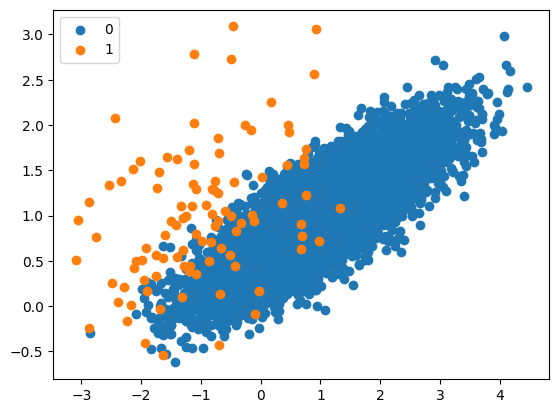

In [21]:
# scatter plot of examples by class label
for label, _ in counter.items():
  row_ix = np.where(y == label)[0]
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

Next, we can oversample the minority class using SMOTE and plot the transformed dataset.

We can use the SMOTE implementation provided by the imbalanced-learn Python library in the SMOTE class.

The SMOTE class acts like a data transform object from scikit-learn in that it must be defined and configured, fit on a dataset, then applied to create a new transformed version of the dataset.

For example, we can define a SMOTE instance with default parameters that will balance the minority class and then fit and apply it in one step to create a transformed version of our dataset.

In [27]:
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

Once transformed, we can summarize the class distribution of the new transformed dataset, which would expect to now be balanced through the creation of many new synthetic examples in the minority class.

In [26]:
# summerize the new class distribution
counter = Counter(y)
print(counter)

Counter({np.int64(0): 9900, np.int64(1): 9900})


A scatter plot of the transformed dataset can also be created and we would expect to see many more examples for the minority class on lines between the original examples in the minority class.

Running the example first creates the dataset and summarizes the class distribution, showing the 1:100 ratio.

Then the dataset is transformed using the SMOTE and the new class distribution is summarized, showing a balanced distribution now with 9,900 examples in the minority class.

Finally, a scatter plot of the transformed dataset is created.

It shows many more examples in the minority class created along the lines between the original examples in the minority class.

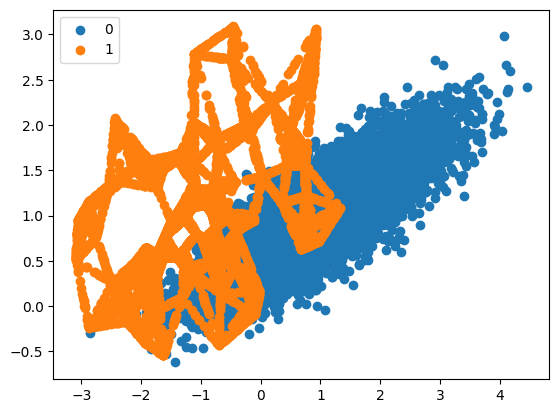

In [28]:
# scatter plot of examples by class label II
for label, _ in counter.items():
  row_ix = where(y == label)[0]
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

The original paper on SMOTE suggested combining SMOTE with random undersampling of the majority class.

The imbalanced-learn library supports random undersampling via the RandomUnderSampler class.

We can update the example to first oversample the minority class to have 10 percent the number of examples of the majority class (e.g. about 1,000), then use random undersampling to reduce the number of examples in the majority class to have 50 percent more than the minority class (e.g. about 2,000).

To implement this, we can specify the desired ratios as arguments to the SMOTE and RandomUnderSampler classes; for example:

In [31]:
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

We can then chain these two transforms together into a Pipeline.

The Pipeline can then be applied to a dataset, performing each transformation in turn and returning a final dataset with the accumulation of the transform applied to it, in this case oversampling followed by undersampling.

In [33]:
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

The pipeline can then be fit and applied to our dataset just like a single transform:

In [40]:
# transform the dataset
X, y = pipeline.fit_resample(X, y)

We can then summarize and plot the resulting dataset.

We would expect some SMOTE oversampling of the minority class, although not as much as before where the dataset was balanced. We also expect fewer examples in the majority class via random undersampling.

Running the example first creates the dataset and summarizes the class distribution.

Next, the dataset is transformed, first by oversampling the minority class, then undersampling the majority class. The final class distribution after this sequence of transforms matches our expectations with a 1:2 ratio or about 2,000 examples in the majority class and about 1,000 examples in the minority class.

Finally, a scatter plot of the transformed dataset is created, showing the oversampled minority class and the undersampled majority class.

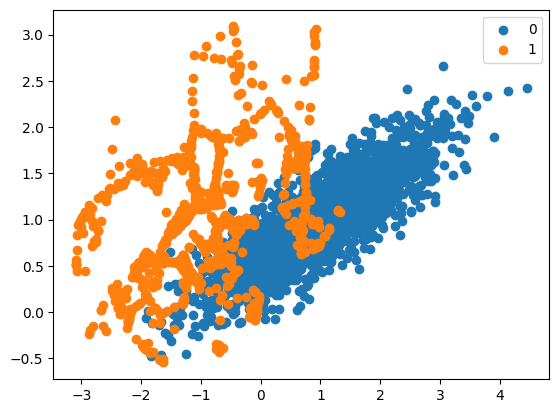

In [41]:
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = where(y == label)[0]
	pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

Now that we are familiar with transforming imbalanced datasets, let’s look at using SMOTE when fitting and evaluating classification models.

SMOTE for Classification

In this section, we will look at how we can use SMOTE as a data preparation method when fitting and evaluating machine learning algorithms in scikit-learn.

First, we use our binary classification dataset from the previous section then fit and evaluate a decision tree algorithm.

The algorithm is defined with any required hyperparameters (we will use the defaults), then we will use repeated stratified k-fold cross-validation to evaluate the model. We will use three repeats of 10-fold cross-validation, meaning that 10-fold cross-validation is applied three times fitting and evaluating 30 models on the dataset.

The dataset is stratified, meaning that each fold of the cross-validation split will have the same class distribution as the original dataset, in this case, a 1:100 ratio. We will evaluate the model using the ROC area under curve (AUC) metric. This can be optimistic for severely imbalanced datasets but will still show a relative change with better performing models.

In [50]:
# define model
model = DecisionTreeClassifier()

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)

Once fit, we can calculate and report the mean of the scores across the folds and repeats.



In [51]:
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.912


We would not expect a decision tree fit on the raw imbalanced dataset to perform very well.

Running the example evaluates the model and reports the mean ROC AUC.

Note: Your results may vary given the stochastic nature of the algorithm or evaluation procedure, or differences in numerical precision. Consider running the example a few times and compare the average outcome.

Now, we can try the same model and the same evaluation method, although use a SMOTE transformed version of the dataset.

The correct application of oversampling during k-fold cross-validation is to apply the method to the training dataset only, then evaluate the model on the stratified but non-transformed test set.

This can be achieved by defining a Pipeline that first transforms the training dataset with SMOTE then fits the model.

In [58]:
# define pipleline
steps = [('over', SMOTE()), ('model', DecisionTreeClassifier())]
pipeline = Pipeline(steps=steps)

This pipeline can then be evaluated using repeated k-fold cross-validation.

In [59]:
# define dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.822


Running the example evaluates the model and reports the mean ROC AUC score across the multiple folds and repeats.

As mentioned in the paper, it is believed that SMOTE performs better when combined with undersampling of the majority class, such as random undersampling.

We can achieve this by simply adding a RandomUnderSampler step to the Pipeline.

As in the previous section, we will first oversample the minority class with SMOTE to about a 1:10 ratio, then undersample the majority class to achieve about a 1:2 ratio.

In [60]:
# define pipeline
model = DecisionTreeClassifier()
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)
steps = [('over', over), ('under', under), ('model', model)]
pipeline = Pipeline(steps=steps)

In [61]:
# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

Mean ROC AUC: 0.845


You could explore testing different ratios of the minority class and majority class (e.g. changing the sampling_strategy argument) to see if a further lift in performance is possible.

Another area to explore would be to test different values of the k-nearest neighbors selected in the SMOTE procedure when each new synthetic example is created. The default is k=5, although larger or smaller values will influence the types of examples created, and in turn, may impact the performance of the model.

For example, we could grid search a range of values of k, such as values from 1 to 7, and evaluate the pipeline for each value.

In [64]:
# values to evaluate
k_values = [1, 2, 3, 4, 5, 6, 7]
for k in k_values:
  # define pipeline
  model = DecisionTreeClassifier()
  over = SMOTE(sampling_strategy=0.1, k_neighbors=k)
  under = RandomUnderSampler(sampling_strategy=0.5)
  steps = [('over', over), ('under', under), ('model', model)]
  pipeline = Pipeline(steps=steps)
  # evaluate pipeline
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
  score = mean(scores)
  print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

> k=1, Mean ROC AUC: 0.834
> k=2, Mean ROC AUC: 0.837
> k=3, Mean ROC AUC: 0.844
> k=4, Mean ROC AUC: 0.850
> k=5, Mean ROC AUC: 0.843
> k=6, Mean ROC AUC: 0.838
> k=7, Mean ROC AUC: 0.852


In this case, the results suggest that a k=7 might be good with a ROC AUC of about 0.85, and k=4 might also be good with a ROC AUC of about 0.85 as well.

This highlights that both the amount of oversampling and undersampling performed (sampling_strategy argument) and the number of examples selected from which a partner is chosen to create a synthetic example (k_neighbors) may be important parameters to select and tune for your dataset.

Now that we are familiar with how to use SMOTE when fitting and evaluating classification models, let’s look at some extensions of the SMOTE procedure.

SMOTE With Selective Synthetic Sample Generation

We can be selective about the examples in the minority class that are oversampled using SMOTE.

In this section, we will review some extensions to SMOTE that are more selective regarding the examples from the minority class that provide the basis for generating new synthetic examples.

Borderline-SMOTE

A popular extension to SMOTE involves selecting those instances of the minority class that are misclassified, such as with a k-nearest neighbor classification model.

We can then oversample just those difficult instances, providing more resolution only where it may be required.

These examples that are misclassified are likely ambiguous and in a region of the edge or border of decision boundary where class membership may overlap. As such, this modified to SMOTE is called Borderline-SMOTE and was proposed by Hui Han, et al. in their 2005 paper titled “Borderline-SMOTE: A New Over-Sampling Method in Imbalanced Data Sets Learning.”

The authors also describe a version of the method that also oversampled the majority class for those examples that cause a misclassification of borderline instances in the minority class. This is referred to as Borderline-SMOTE1, whereas the oversampling of just the borderline cases in minority class is referred to as Borderline-SMOTE2.

We can implement Borderline-SMOTE1 using the BorderlineSMOTE class from imbalanced-learn.

We can demonstrate the technique on the synthetic binary classification problem used in the previous sections.

Instead of generating new synthetic examples for the minority class blindly, we would expect the Borderline-SMOTE method to only create synthetic examples along the decision boundary between the two classes.

Counter({np.int64(0): 9900, np.int64(1): 9900})
Counter({np.int64(0): 9900, np.int64(1): 9900})


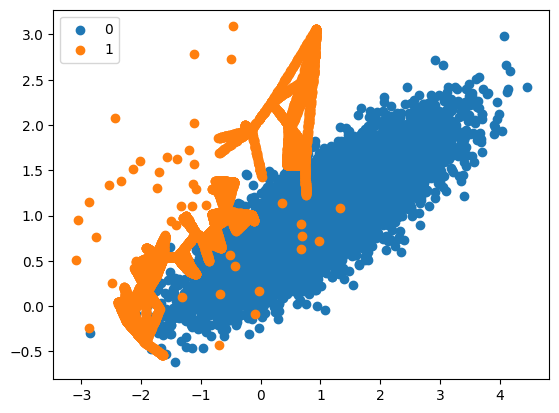

In [67]:
oversample = BorderlineSMOTE()
X, y = oversample.fit_resample(X, y)
# summarize class disribution
counter = Counter(y)
print(counter)
# transform the dataset
oversample = BorderlineSMOTE()
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
  row_ix = where(y == label)[0]
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

Running the example first creates the dataset and summarizes the initial class distribution, showing a 1:100 relationship.

The Borderline-SMOTE is applied to balance the class distribution, which is confirmed with the printed class summary.

Finally, a scatter plot of the transformed dataset is created. The plot clearly shows the effect of the selective approach to oversampling. Examples along the decision boundary of the minority class are oversampled intently (orange).

The plot shows that those examples far from the decision boundary are not oversampled. This includes both examples that are easier to classify (those orange points toward the top left of the plot) and those that are overwhelmingly difficult to classify given the strong class overlap (those orange points toward the bottom right of the plot).

Borderline-SMOTE SVM

Hien Nguyen, et al. suggest using an alternative of Borderline-SMOTE where an SVM algorithm is used instead of a KNN to identify misclassified examples on the decision boundary.

Their approach is summarized in the 2009 paper titled “Borderline Over-sampling For Imbalanced Data Classification.” An SVM is used to locate the decision boundary defined by the support vectors and examples in the minority class that close to the support vectors become the focus for generating synthetic examples.



"… the borderline area is approximated by the support vectors obtained after training a standard SVMs classifier on the original training set. New instances will be randomly created along the lines joining each minority class support vector with a number of its nearest neighbors using the interpolation"

In addition to using an SVM, the technique attempts to select regions where there are fewer examples of the minority class and tries to extrapolate towards the class boundary.

"If majority class instances count for less than a half of its nearest neighbors, new instances will be created with extrapolation to expand minority class area toward the majority class."

This variation can be implemented via the SVMSMOTE class from the imbalanced-learn library.

Counter({np.int64(0): 9900, np.int64(1): 100})
Counter({np.int64(0): 9900, np.int64(1): 9900})


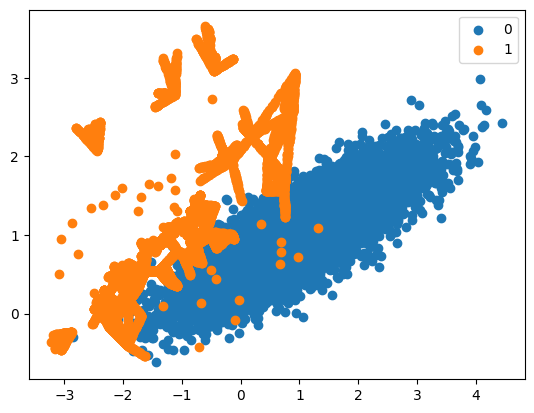

In [4]:
# define the dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# summarize class distribution
counter = Counter(y)
print(counter)

# transform the dataset
oversample = SVMSMOTE()
X, y = oversample.fit_resample(X, y)

# summarize the new class distribution
counter = Counter(y)
print(counter)

# scatter plot of examples by class label
for label, _ in counter.items():
  row_ix = where(y == label)[0]
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

We can also see that unlike Borderline-SMOTE, more examples are synthesized away from the region of class overlap, such as toward the top left of the plot.

**Adaptive Synthetic Sampling (ADASYN)**


Another approach involves generating synthetic samples inversely proportional to the density of the examples in the minority class.

That is, generate more synthetic examples in regions of the feature space where the density of minority examples is low, and fewer or none where the density is high.

This modification to SMOTE is referred to as the Adaptive Synthetic Sampling Method, or ADASYN, and was proposed to Haibo He, et al. in their 2008 paper named for the method titled “ADASYN: Adaptive Synthetic Sampling Approach For Imbalanced Learning.”

"ADASYN is based on the idea of adaptively generating minority data samples according to their distributions: more synthetic data is generated for minority class samples that are harder to learn compared to those minority samples that are easier to learn."

We can implement this procedure using the ADASYN class in the imbalanced-learn library.

Counter({np.int64(0): 9900, np.int64(1): 100})
Counter({np.int64(0): 9900, np.int64(1): 9899})


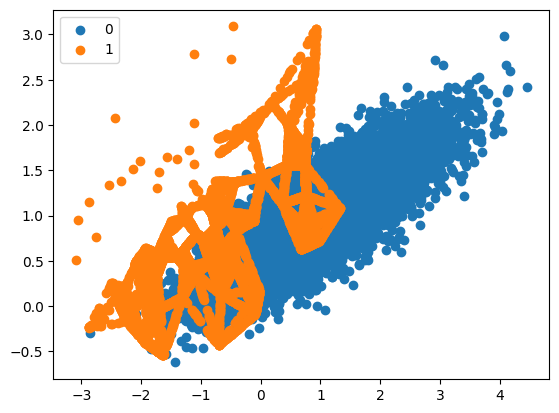

In [7]:
# define the dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# summarize class distribution
counter = Counter(y)
print(counter)

# transform the dataset
oversample = ADASYN()
X, y = oversample.fit_resample(X, y)

# summarize the new class distribution
counter = Counter(y)
print(counter)

# scatter plot of examples by class label
for label, _ in counter.items():
  row_ix = where(y == label)[0]
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

Unlike Borderline-SMOTE, we can see that the examples that have the most class overlap have the most focus. On problems where these low density examples might be outliers, the ADASYN approach may put too much attention on these areas of the feature space, which may result in worse model performance.

It may help to remove outliers prior to applying the oversampling procedure, and this might be a helpful heuristic to use more generally.